In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import os
from pathlib import Path

In [2]:
# Add src to path for imports
os.chdir(os.path.dirname(os.path.abspath('.'))) 

In [3]:
from src.battery.battery import BatteryConfig
from src.battery.lp_optimizer import LPOptimizer
from src.battery.fetcher import compute_price_statistics

── 0. Configuration ─────────────────────────────────────────────────────────

In [4]:
battery = BatteryConfig(
    power_mw=100.0,
    capacity_mwh=400.0,
    rte_charge=0.93,
    rte_discharge=0.95,
    degradation_cost=10.0,
    soc_min_pct=0.05,
    soc_max_pct=0.95,
    soc_initial_pct=0.50,
)

In [5]:
optimizer = LPOptimizer(battery, dt_hours=1.0)

In [6]:
print("Battery configuration:")
print(f"  {battery}")
print(f"  Minimum profitable spread: ${battery.minimum_profitable_spread():.2f}/MWh")
print(f"  Usable capacity: {battery.usable_capacity_mwh:.0f} MWh")

Battery configuration:
  BatteryConfig(100.0MW / 400.0MWh, RTE=88.3%, degradation=$10.0/MWh)
  Minimum profitable spread: $21.32/MWh
  Usable capacity: 360 MWh


── 1. Load Prices ────────────────────────────────────────────────────────────

In [22]:
from src.battery.fetcher import fetch_caiso_prices, fetch_ercot_prices, process_ercot_data
# prices_ercot = fetch_ercot_prices("2025-01-01", "2025-12-31")
# ERCOT API does not provide historical data that far back

prices_caiso = fetch_caiso_prices("2025-01-02", "2025-02-01")

2026-04-13 18:36:10 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'PRC_LMP', 'version': 12}, 'params': {'market_run_id': 'DAM', 'node': None, 'grp_type': [None, 'ALL', 'ALL_APNODES']}}
2026-04-13 18:36:10 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=PRC_LMP&version=12&market_run_id=DAM&node=TH_NP15_GEN-APND&startdatetime=20250102T08:00-0000&enddatetime=20250201T08:00-0000


  Fetching CAISO 2025-01-02 to 2025-02-01...


c:\Users\grego\Documents\Github\Battery Optimiser\.venv\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'oasis.caiso.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
2026-04-13 18:36:15 - DEBUG - Found 1 files: ['20250102_20250201_PRC_LMP_DAM_20260413_15_36_10_v12.csv']
2026-04-13 18:36:15 - DEBUG - Parsing file: 20250102_20250201_PRC_LMP_DAM_20260413_15_36_10_v12.csv


In [23]:
data_raw = Path("__file__").resolve().parent / "data" / "raw"
df_ercot = process_ercot_data(data_raw)
prices_ercot = df_ercot["LMP"]

In [24]:
print(f"\nCAISO prices:")
print(f"  Min: ${prices_caiso.min():.1f}/MWh at hour {prices_caiso.idxmin().hour}")
print(f"  Max: ${prices_caiso.max():.1f}/MWh at hour {prices_caiso.idxmax().hour}")
print(f"  Spread: ${prices_caiso.max() - prices_caiso.min():.1f}/MWh")


CAISO prices:
  Min: $6.3/MWh at hour 13
  Max: $91.7/MWh at hour 6
  Spread: $85.4/MWh


In [25]:
print(f"\nERCOT prices:")
print(f"  Min: ${prices_ercot.min():.1f}/MWh at hour {prices_ercot.idxmin().hour}")
print(f"  Max: ${prices_ercot.max():.1f}/MWh at hour {prices_ercot.idxmax().hour}")
print(f"  Spread: ${prices_ercot.max() - prices_ercot.min():.1f}/MWh")


ERCOT prices:
  Min: $-0.1/MWh at hour 2
  Max: $162.7/MWh at hour 7
  Spread: $162.8/MWh


In [26]:
# NaN analysis
print(prices_caiso.resample('D').apply(lambda x: x.isna().sum()).value_counts())
prices_caiso = prices_caiso.ffill()

LMP
0    30
Name: count, dtype: int64


In [27]:
# ── Data Shape Analysis ─────────────────────────────────────────────────────

for name, prices in [("CAISO", prices_caiso), ("ERCOT", prices_ercot)]:
    total = len(prices)
    missing = prices.isna().sum()
    pct_missing = 100 * missing / total if total else 0

    start, end = prices.index.min(), prices.index.max()
    span = end - start

    # Expected hourly count for the span
    expected = int(span.total_seconds() / 3600) + 1
    gaps = expected - total  # hours not even in the index

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"  Period:       {start}  →  {end}")
    print(f"  Span:         {span.days} days ({span.days/365.25:.1f} years)")
    print(f"  Index length: {total:,} rows")
    print(f"  Expected hrs: {expected:,}")
    print(f"  NaN values:   {missing} ({pct_missing:.2f}%)")
    print(f"  Index gaps:   {gaps} hours missing from index")
    print(f"  dtype:        {prices.dtype}")

    # Show where NaNs cluster (by month)
    if missing > 0:
        nan_by_month = prices.isna().groupby(prices.index.to_period('M')).sum()
        print(f"  NaNs by month:")
        for period, count in nan_by_month[nan_by_month > 0].items():
            print(f"    {period}: {int(count)} missing hours")

    # Check for consecutive gaps
    if missing > 0:
        is_nan = prices.isna()
        groups = (is_nan != is_nan.shift()).cumsum()
        nan_runs = is_nan.groupby(groups).sum()
        nan_runs = nan_runs[nan_runs > 0]
        print(f"  Longest consecutive gap: {int(nan_runs.max())} hours")
        print(f"  Number of gap segments:  {len(nan_runs)}")



CAISO
  Period:       2025-01-02 00:00:00  →  2025-01-31 23:00:00
  Span:         29 days (0.1 years)
  Index length: 720 rows
  Expected hrs: 720
  NaN values:   0 (0.00%)
  Index gaps:   0 hours missing from index
  dtype:        float64

ERCOT
  Period:       2025-01-02 00:00:00  →  2025-02-01 23:00:00
  Span:         30 days (0.1 years)
  Index length: 744 rows
  Expected hrs: 744
  NaN values:   0 (0.00%)
  Index gaps:   0 hours missing from index
  dtype:        float64


── 2. Solve the LP ───────────────────────────────────────────────────────────

In [28]:
print("\nSolving LP for CAISO year...")


Solving LP for CAISO year...


In [29]:
result_caiso = optimizer.solve(prices_caiso.values)
print(f"Status: {result_caiso.status}")
print(f"Total revenue: ${result_caiso.total_revenue:.2f}")
print(f"Cycles: {result_caiso.n_cycles:.2f}")

Status: optimal
Total revenue: $111343.02
Cycles: 21.63


In [30]:
print("\nSolving LP for ERCOT year...")


Solving LP for ERCOT year...


In [31]:
result_ercot = optimizer.solve(prices_ercot.values)
print(f"Status: {result_ercot.status}")
print(f"Total revenue: ${result_ercot.total_revenue:.2f}")
print(f"Cycles: {result_ercot.n_cycles:.2f}")

Status: optimal
Total revenue: $150308.14
Cycles: 16.85


── 3. Plot: SOC + Price Overlay ─────────────────────────────────────────────

In [32]:
def plot_dispatch(prices: pd.Series, result, battery: BatteryConfig, title: str):
    """
    Standard dispatch visualization: prices on top, SOC on bottom.

    This is the primary diagnostic plot. For any result you generate,
    you should be able to look at this plot and understand why the battery
    made the decisions it did.
    """
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1.5, 1])

    hours = np.arange(len(prices))

    # Panel 1: Prices
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(hours, prices.values, 'k-', linewidth=2, label='Price')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.fill_between(hours, prices.values, 0,
                     where=(prices.values < 0), alpha=0.3, color='red',
                     label='Negative price')
    ax1.set_ylabel('Price ($/MWh)')
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if result is not None:
        # Panel 2: Charge/Discharge
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        ax2.bar(hours, result.discharge_mw, color='green', alpha=0.7,
                label='Discharge (revenue)')
        ax2.bar(hours, -result.charge_mw, color='red', alpha=0.7,
                label='Charge (cost)')
        ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        ax2.set_ylabel('Power (MW)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # Panel 3: SOC
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        ax3.fill_between(range(len(result.soc_mwh)), result.soc_mwh,
                         battery.soc_min_mwh, alpha=0.5, color='blue')
        ax3.axhline(y=battery.soc_max_mwh, color='red', linestyle='--',
                    alpha=0.5, label=f'SOC max ({battery.soc_max_mwh:.0f} MWh)')
        ax3.axhline(y=battery.soc_min_mwh, color='orange', linestyle='--',
                    alpha=0.5, label=f'SOC min ({battery.soc_min_mwh:.0f} MWh)')
        ax3.set_ylabel('SOC (MWh)')
        ax3.set_xlabel('Hour')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


Saved price plot to results/plots/01_caiso_prices.png


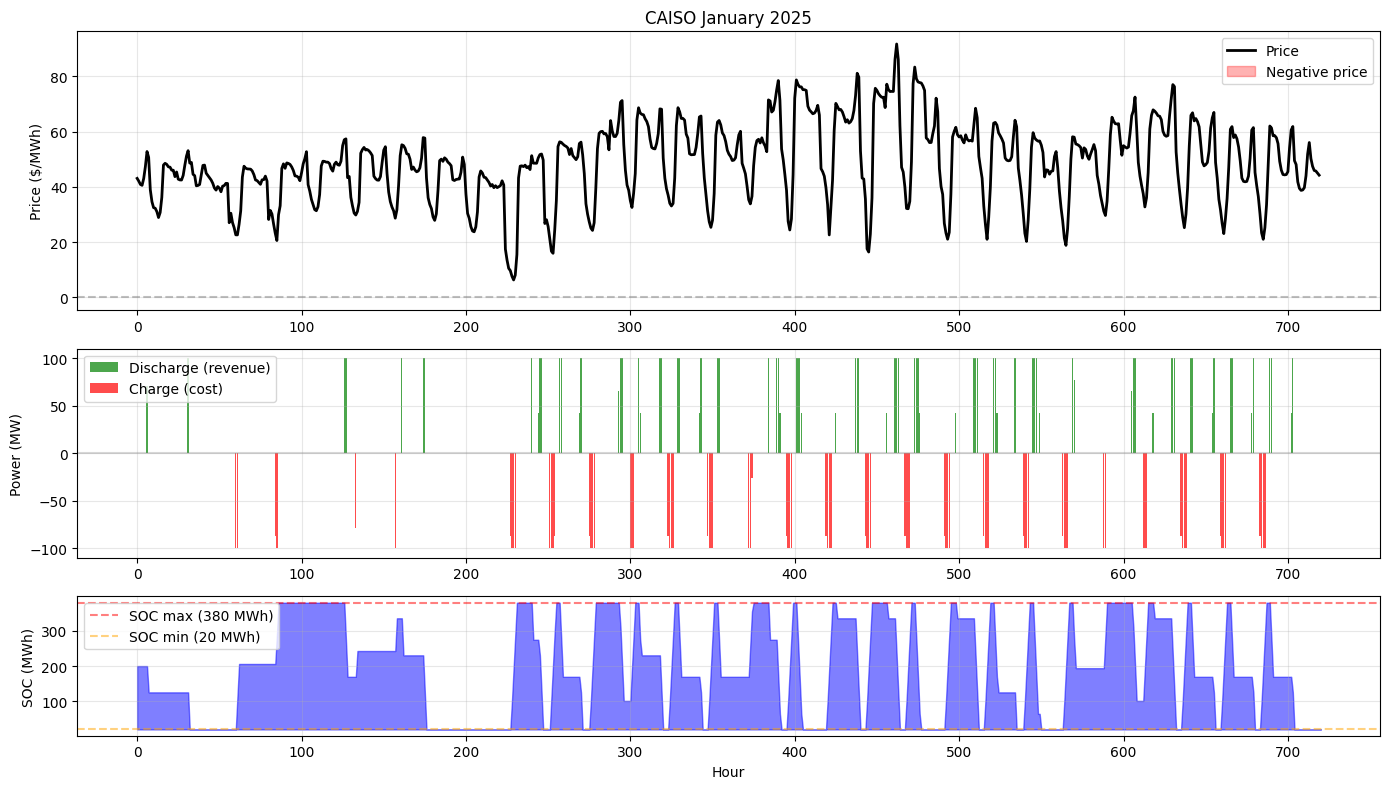

In [37]:
# Plot
fig = plot_dispatch(prices_caiso, result=result_caiso, battery=battery,
                    title="CAISO January 2025")
plt.savefig("results/plots/01_caiso_jan.png", dpi=150, bbox_inches='tight')
print("\nSaved price plot to results/plots/01_caiso_prices.png")


Saved price plot to results/plots/01_ercot_prices.png


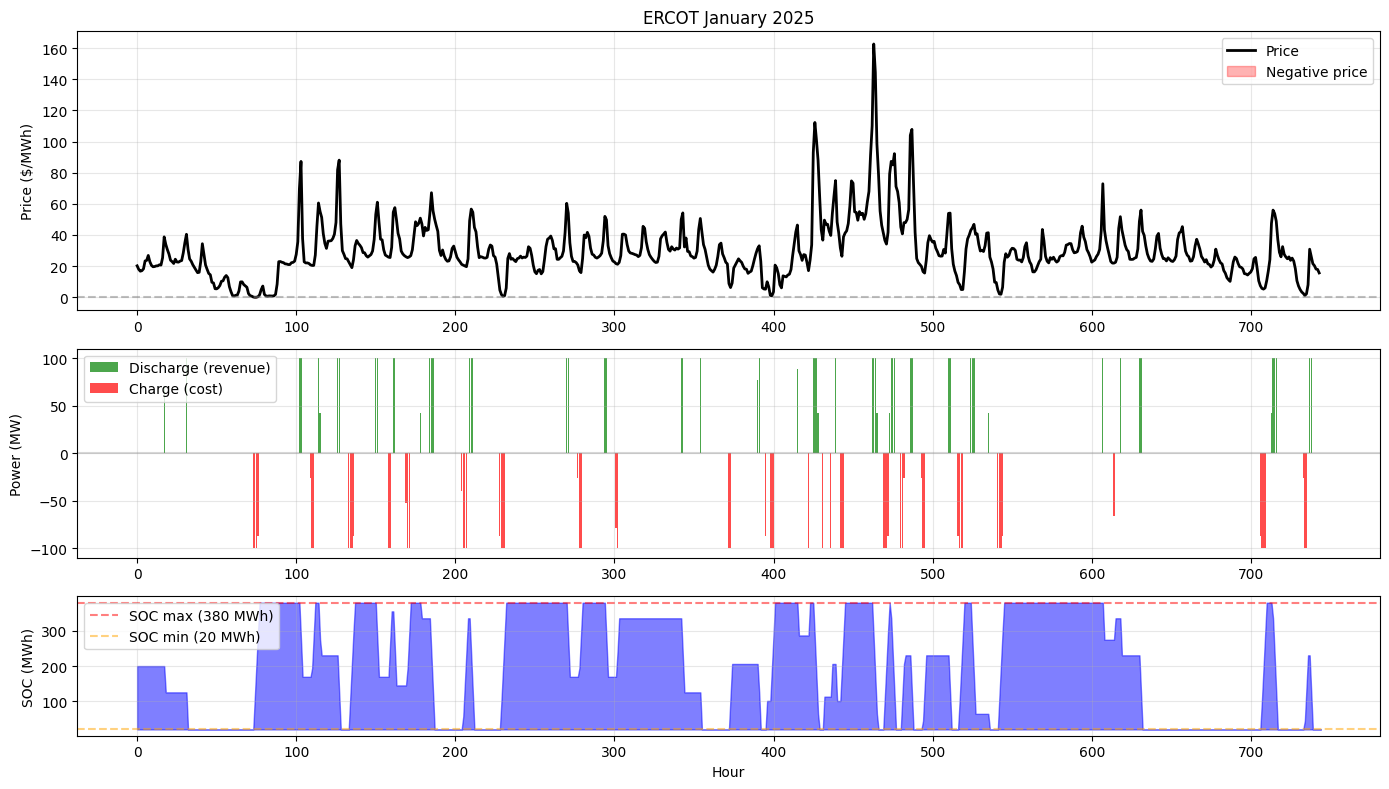

In [38]:
# Plot
fig = plot_dispatch(prices_ercot, result=result_ercot, battery=battery,
                    title="ERCOT January 2025")
plt.savefig("results/plots/01_ercot_jan.png", dpi=150, bbox_inches='tight')
print("\nSaved price plot to results/plots/01_ercot_prices.png")

── 4. Revenue Metrics ────────────────────────────────────────────────────────

In [42]:
print(f"\nCAISO Revenue metrics:")
print(f"  Total revenue: ${result_caiso.total_revenue:.2f}")
print(f"  Annualized ($/kW-yr): ${result_caiso.revenue_per_kw_yr:.2f}")
print(f"  Number of cycles: {result_caiso.n_cycles:.2f}")

print(f"\nERCOT Revenue metrics:")
print(f"  Total revenue: ${result_ercot.total_revenue:.2f}")
print(f"  Annualized ($/kW-yr): ${result_ercot.revenue_per_kw_yr:.2f}")
print(f"  Number of cycles: {result_ercot.n_cycles:.2f}")


CAISO Revenue metrics:
  Total revenue: $111343.02
  Annualized ($/kW-yr): $13.55
  Number of cycles: 21.63

ERCOT Revenue metrics:
  Total revenue: $150308.14
  Annualized ($/kW-yr): $17.70
  Number of cycles: 16.85


In [40]:
# Price statistics (doesn't require LP)
print("\nCAISO price statistics:")
stats = compute_price_statistics(prices_caiso)
for k, v in stats.items():
    print(f"  {k}: {v:.2f}")

print("\n")

print("\nERCOT price statistics:")
stats = compute_price_statistics(prices_ercot)
for k, v in stats.items():
    print(f"  {k}: {v:.2f}")


CAISO price statistics:
  mean_price: 48.54
  std_price: 14.10
  min_price: 6.28
  max_price: 91.71
  pct_negative: 0.00
  pct_above_100: 0.00
  pct_above_200: 0.00
  daily_spread_mean: 37.49
  daily_spread_p90: 52.05



ERCOT price statistics:
  mean_price: 29.57
  std_price: 18.00
  min_price: -0.10
  max_price: 162.66
  pct_negative: 0.27
  pct_above_100: 0.94
  pct_above_200: 0.00
  daily_spread_mean: 42.14
  daily_spread_p90: 69.10


── 5. CAISO vs ERCOT Comparison ─────────────────────────────────────────────

In [41]:
print(f"\nMarket comparison (single day):")
print(f"  {'Metric':<30} {'ERCOT':>12} {'CAISO':>12}")
print(f"  {'-'*54}")
print(f"  {'Revenue ($)':<30} {result_ercot.total_revenue:>12.2f} {result_caiso.total_revenue:>12.2f}")
print(f"  {'Cycles':<30} {result_ercot.n_cycles:>12.2f} {result_caiso.n_cycles:>12.2f}")
print(f"  {'Price spread ($/MWh)':<30} ...")



Market comparison (single day):
  Metric                                ERCOT        CAISO
  ------------------------------------------------------
  Revenue ($)                       150308.14    111343.02
  Cycles                                16.85        21.63
  Price spread ($/MWh)           ...
